Total Transactions loaded: 9835
Example Transaction 1: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']

Found 122 frequent itemsets.

--- Top 5 Association Rules Found ---
                       antecedents         consequents   support  confidence  \
33  (whole milk, other vegetables)   (root vegetables)  0.023183    0.309783   
32   (whole milk, root vegetables)  (other vegetables)  0.023183    0.474012   
17               (root vegetables)  (other vegetables)  0.047382    0.434701   
19            (whipped/sour cream)  (other vegetables)  0.028876    0.402837   
35            (whole milk, yogurt)  (other vegetables)  0.022267    0.397459   

        lift  
33  2.842082  
32  2.449770  
17  2.246605  
19  2.081924  
35  2.054131  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


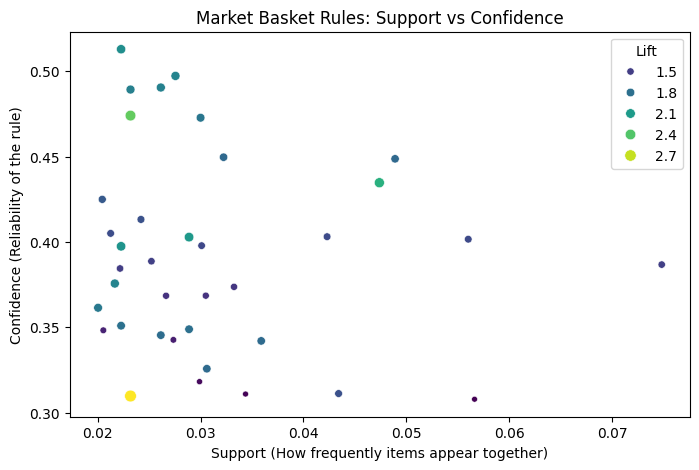

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
# 1. Install and import libraries
!pip install mlxtend pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

# 2. Load the Dataset
# We will use a reliable, public transactional grocery dataset directly from GitHub
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

# Since it's a raw list of transactions without fixed columns, we read it carefully
with open("/tmp/groceries.csv" if "google.colab" in str(get_ipython()) else "groceries.csv", "w") as f:
    import urllib.request
    urllib.request.urlretrieve(url, f.name)

with open("/tmp/groceries.csv" if "google.colab" in str(get_ipython()) else "groceries.csv", "r") as f:
    lines = f.readlines()

transactions = [line.strip().split(',') for line in lines]

print(f"Total Transactions loaded: {len(transactions)}")
print(f"Example Transaction 1: {transactions[0]}")

# 3. One-Hot Encode the Transactions
# The Apriori algorithm requires a binary matrix (True/False or 1/0) for items
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# 4. Apply the Apriori Algorithm
# Find items/itemsets bought together frequently (min_support = 2% of all transactions)
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
print(f"\nFound {len(frequent_itemsets)} frequent itemsets.")

# 5. Generate Association Rules
# Filter rules where the probability of item B being bought given item A is at least 30% (confidence >= 0.3)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Sort rules by 'lift' to find the strongest item associations
rules = rules.sort_values(by="lift", ascending=False)

print("\n--- Top 5 Association Rules Found ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# 6. Visualize the Rules (Scatter Plot: Confidence vs Support)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=rules['support'], y=rules['confidence'], hue=rules['lift'], palette='viridis', size=rules['lift'])
plt.title('Market Basket Rules: Support vs Confidence')
plt.xlabel('Support (How frequently items appear together)')
plt.ylabel('Confidence (Reliability of the rule)')
plt.legend(title='Lift')
plt.show()